<a href="https://colab.research.google.com/github/lauraaguilargonzalez18/estadisticaverano2026/blob/main/Actividad_de_recuperacion_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/lauraaguilargonzalez18/estadisticaverano2026/refs/heads/main/Maternal%20Health%20Risk%20Data%20Set.csv")

df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


## **MODELO 1**

In [2]:
x = df["SystolicBP"]   # Variable independiente
y = df["DiastolicBP"]  # Variable dependiente


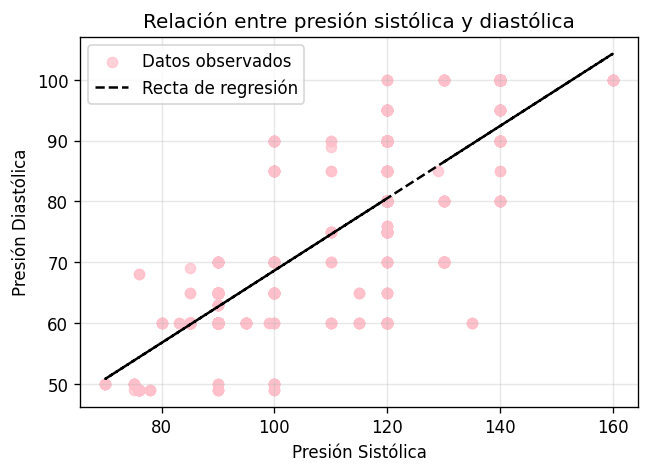

In [3]:
import statsmodels.api as sm

x_const = sm.add_constant(x)
modelo1 = sm.OLS(y, x_const).fit()
y_pred = modelo1.predict(x_const)

# Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(x, y, color="pink", alpha=0.7, label="Datos observados")
plt.plot(x, y_pred, color="black", linestyle="--", label="Recta de regresión")
plt.xlabel("Presión Sistólica")
plt.ylabel("Presión Diastólica")
plt.title("Relación entre presión sistólica y diastólica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [4]:
print("Intercepto (b0):", modelo1.params[0])
print("Pendiente (b1):", modelo1.params[1])


Intercepto (b0): 9.243644540040725
Pendiente (b1): 0.5937982491867153


/tmp/ipykernel_28353/1101165590.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Intercepto (b0):", modelo1.params[0])
/tmp/ipykernel_28353/1101165590.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Pendiente (b1):", modelo1.params[1])


In [5]:
print(modelo1.summary())


                            OLS Regression Results                            
Dep. Variable:            DiastolicBP   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     1647.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):          1.71e-214
Time:                        19:17:42   Log-Likelihood:                -3616.3
No. Observations:                1014   AIC:                             7237.
Df Residuals:                    1012   BIC:                             7246.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.2436      1.678      5.508      0.0

In [6]:
from statsmodels.formula.api import ols
modelo_lineal1 = ols("DiastolicBP ~ SystolicBP", data=df).fit()
anova_tabla1 = sm.stats.anova_lm(modelo_lineal1)
print(anova_tabla1)


                df         sum_sq        mean_sq            F         PR(>F)
SystolicBP     1.0  120978.334832  120978.334832  1646.814196  1.706941e-214
Residual    1012.0   74343.587258      73.462043          NaN            NaN


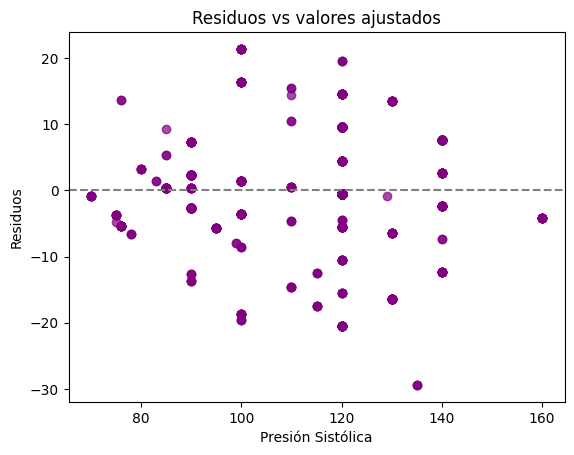

In [7]:
plt.scatter(x, modelo1.resid, color="purple", alpha=0.7)
plt.axhline(y=0, color="gray", linestyle="--")
plt.xlabel("Presión Sistólica")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()


In [8]:
from statsmodels.stats.stattools import durbin_watson
dw1 = durbin_watson(modelo1.resid)
print("Durbin-Watson:", dw1)


Durbin-Watson: 1.766865889872241


Shapiro-Wilk valor-p: 4.402414867445759e-18


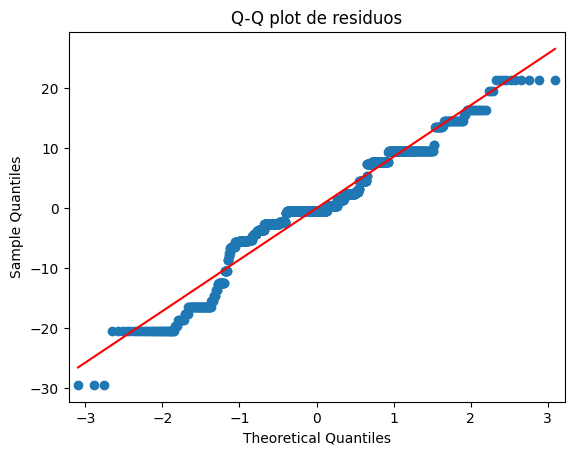

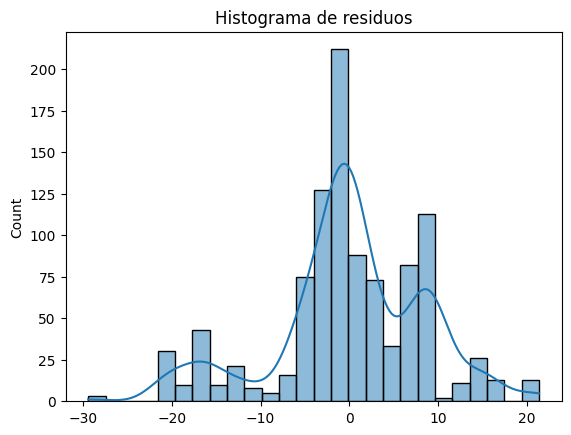

In [9]:
from scipy.stats import shapiro
stat, p_shapiro1 = shapiro(modelo1.resid)
print("Shapiro-Wilk valor-p:", p_shapiro1)

sm.qqplot(modelo1.resid, line="s")
plt.title("Q-Q plot de residuos")
plt.show()

import seaborn as sns
sns.histplot(modelo1.resid, kde=True)
plt.title("Histograma de residuos")
plt.show()


In [10]:
from statsmodels.stats.api import het_breuschpagan
bp_test1 = het_breuschpagan(modelo1.resid, x_const)
print("Breusch-Pagan valor-p:", bp_test1[1])


Breusch-Pagan valor-p: 1.482195990002994e-07


In [11]:
from scipy.stats import pearsonr
r1, p_valor1 = pearsonr(x, y)
print("Coeficiente de correlación:", r1)
print("Valor-p:", p_valor1)
print("Coeficiente de determinación (R2):", r1**2)


Coeficiente de correlación: 0.7870064769775309
Valor-p: 1.7069405087788917e-214
Coeficiente de determinación (R2): 0.6193791948045849


In [12]:
valor1 = modelo1.predict([1,120])  # Ejemplo con presión sistólica = 120
print("Estimación de presión diastólica:", valor1[0])


Estimación de presión diastólica: 80.49943444244656


## **MODELO 2**
## **Relación entre Edad y Frecuencia cardiaca**

In [13]:
x = df["Age"]          # Variable independiente
y = df["HeartRate"]    # Variable dependiente


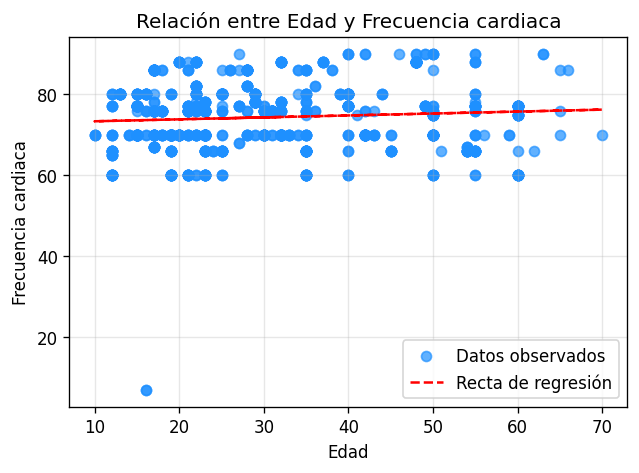

In [14]:
import statsmodels.api as sm

x_const = sm.add_constant(x)
modelo2 = sm.OLS(y, x_const).fit()
y_pred = modelo2.predict(x_const)

# Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(x, y, color="dodgerblue", alpha=0.7, label="Datos observados")
plt.plot(x, y_pred, color="red", linestyle="--", label="Recta de regresión")
plt.xlabel("Edad")
plt.ylabel("Frecuencia cardiaca")
plt.title("Relación entre Edad y Frecuencia cardiaca")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [15]:
print("Intercepto (b0):", modelo2.params[0])
print("Pendiente (b1):", modelo2.params[1])


Intercepto (b0): 72.87083582501032
Pendiente (b1): 0.047902689780107255


/tmp/ipykernel_28353/72049314.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Intercepto (b0):", modelo2.params[0])
/tmp/ipykernel_28353/72049314.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Pendiente (b1):", modelo2.params[1])


In [16]:
print(modelo2.summary())


                            OLS Regression Results                            
Dep. Variable:              HeartRate   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     6.485
Date:                Fri, 17 Jul 2026   Prob (F-statistic):             0.0110
Time:                        19:17:44   Log-Likelihood:                -3554.8
No. Observations:                1014   AIC:                             7114.
Df Residuals:                    1012   BIC:                             7123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         72.8708      0.616    118.228      0.0

In [17]:
from statsmodels.formula.api import ols
modelo_lineal2 = ols("HeartRate ~ Age", data=df).fit()
anova_tabla2 = sm.stats.anova_lm(modelo_lineal2)
print(anova_tabla2)


              df        sum_sq     mean_sq         F    PR(>F)
Age          1.0    422.033751  422.033751  6.485371  0.011024
Residual  1012.0  65855.623053   65.074726       NaN       NaN


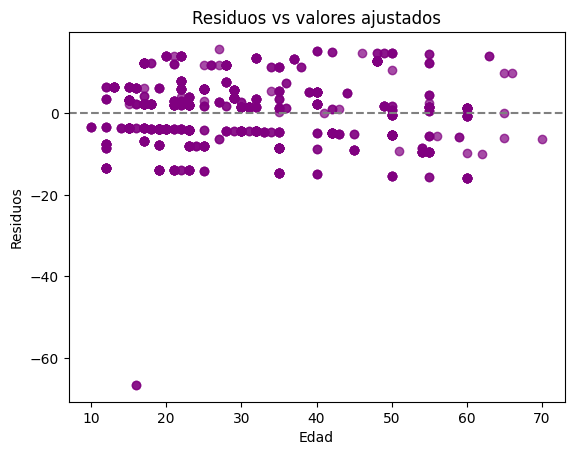

In [18]:
plt.scatter(x, modelo2.resid, color="purple", alpha=0.7)
plt.axhline(y=0, color="gray", linestyle="--")
plt.xlabel("Edad")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()


In [19]:
from statsmodels.stats.stattools import durbin_watson
dw2 = durbin_watson(modelo2.resid)
print("Durbin-Watson:", dw2)


Durbin-Watson: 2.14392939739107


Shapiro-Wilk valor-p: 1.5657327059691782e-22


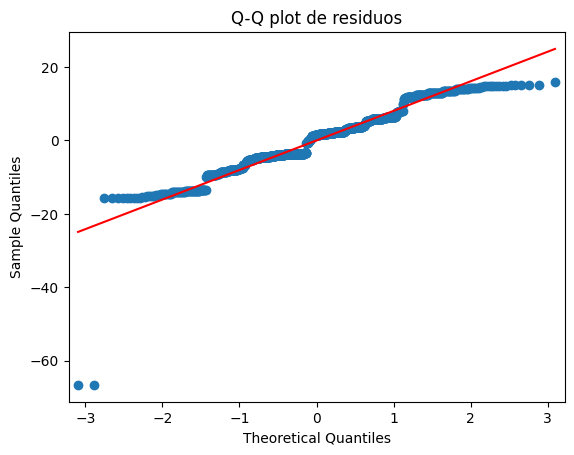

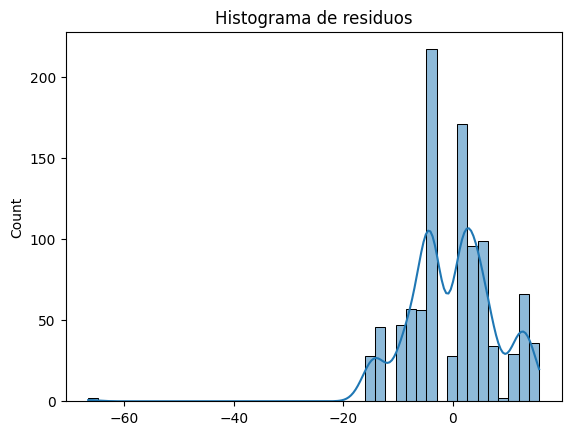

In [20]:
from scipy.stats import shapiro
stat, p_shapiro2 = shapiro(modelo2.resid)
print("Shapiro-Wilk valor-p:", p_shapiro2)

sm.qqplot(modelo2.resid, line="s")
plt.title("Q-Q plot de residuos")
plt.show()

import seaborn as sns
sns.histplot(modelo2.resid, kde=True)
plt.title("Histograma de residuos")
plt.show()


In [21]:
from statsmodels.stats.api import het_breuschpagan
bp_test2 = het_breuschpagan(modelo2.resid, x_const)
print("Breusch-Pagan valor-p:", bp_test2[1])


Breusch-Pagan valor-p: 0.9050873505828927


In [22]:
from scipy.stats import pearsonr
r2, p_valor2 = pearsonr(x, y)
print("Coeficiente de correlación:", r2)
print("Valor-p:", p_valor2)
print("Coeficiente de determinación (R2):", r2**2)


Coeficiente de correlación: 0.07979763482857781
Valor-p: 0.011023733692717943
Coeficiente de determinación (R2): 0.006367662524235054


In [23]:
valor2 = modelo2.predict([1,30])  # Ejemplo con Edad = 30 años
print("Estimación de frecuencia cardiaca:", valor2[0])


Estimación de frecuencia cardiaca: 74.30791651841353


## **MODELO 3**
## **RELACION ENTRE GLUCOSA EN SANGRE Y PRESION**

In [24]:
x = df["BS"]            # Variable independiente
y = df["SystolicBP"]    # Variable dependiente


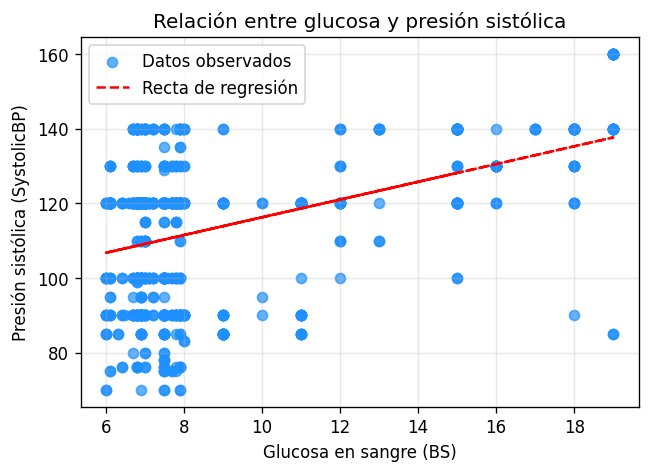

In [25]:
import statsmodels.api as sm

x_const = sm.add_constant(x)
modelo3 = sm.OLS(y, x_const).fit()
y_pred = modelo3.predict(x_const)

# Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(x, y, color="dodgerblue", alpha=0.7, label="Datos observados")
plt.plot(x, y_pred, color="red", linestyle="--", label="Recta de regresión")
plt.xlabel("Glucosa en sangre (BS)")
plt.ylabel("Presión sistólica (SystolicBP)")
plt.title("Relación entre glucosa y presión sistólica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [26]:
print("Intercepto (b0):", modelo3.params[0])
print("Pendiente (b1):", modelo3.params[1])


Intercepto (b0): 92.46689581162663
Pendiente (b1): 2.3758150174907215


/tmp/ipykernel_28353/4245205419.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Intercepto (b0):", modelo3.params[0])
/tmp/ipykernel_28353/4245205419.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Pendiente (b1):", modelo3.params[1])


In [27]:
print(modelo3.summary())


                            OLS Regression Results                            
Dep. Variable:             SystolicBP   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     223.3
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           8.95e-46
Time:                        19:17:45   Log-Likelihood:                -4290.6
No. Observations:                1014   AIC:                             8585.
Df Residuals:                    1012   BIC:                             8595.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         92.4669      1.483     62.362      0.0

In [28]:
from statsmodels.formula.api import ols
modelo_lineal3 = ols("SystolicBP ~ BS", data=df).fit()
anova_tabla3 = sm.stats.anova_lm(modelo_lineal3)
print(anova_tabla3)


              df         sum_sq       mean_sq           F        PR(>F)
BS           1.0   62023.803204  62023.803204  223.307741  8.950869e-46
Residual  1012.0  281083.353601    277.750349         NaN           NaN


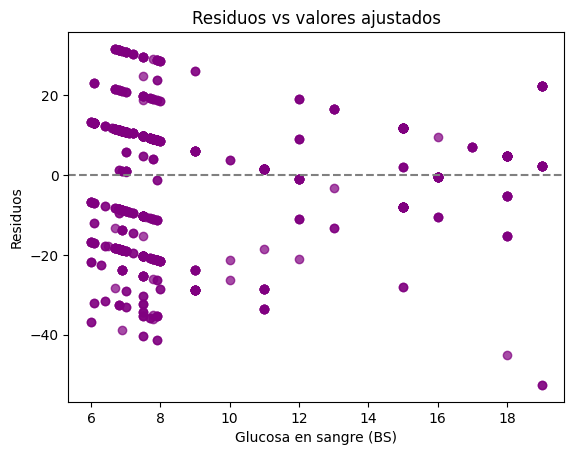

In [29]:
plt.scatter(x, modelo3.resid, color="purple", alpha=0.7)
plt.axhline(y=0, color="gray", linestyle="--")
plt.xlabel("Glucosa en sangre (BS)")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()


In [30]:
from statsmodels.stats.stattools import durbin_watson
dw3 = durbin_watson(modelo3.resid)
print("Durbin-Watson:", dw3)


Durbin-Watson: 2.1346946731493293


Shapiro-Wilk valor-p: 3.6540272051260606e-20


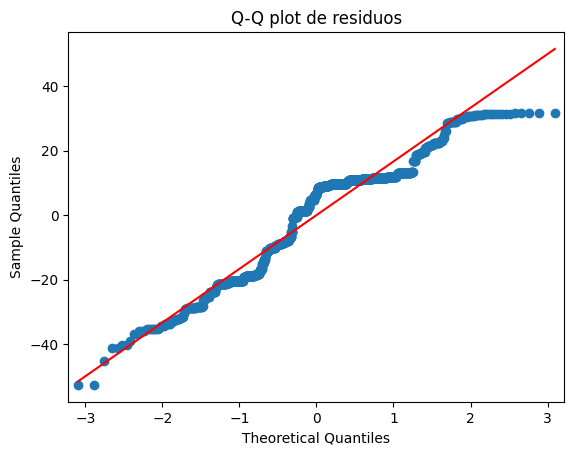

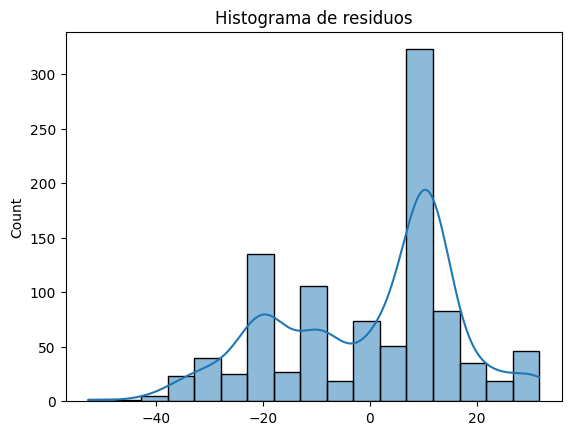

In [31]:
from scipy.stats import shapiro
stat, p_shapiro3 = shapiro(modelo3.resid)
print("Shapiro-Wilk valor-p:", p_shapiro3)

sm.qqplot(modelo3.resid, line="s")
plt.title("Q-Q plot de residuos")
plt.show()

import seaborn as sns
sns.histplot(modelo3.resid, kde=True)
plt.title("Histograma de residuos")
plt.show()


In [32]:
from statsmodels.stats.api import het_breuschpagan
bp_test3 = het_breuschpagan(modelo3.resid, x_const)
print("Breusch-Pagan valor-p:", bp_test3[1])


Breusch-Pagan valor-p: 0.001614784220191761


In [33]:
from scipy.stats import pearsonr
r3, p_valor3 = pearsonr(x, y)
print("Coeficiente de correlación:", r3)
print("Valor-p:", p_valor3)
print("Coeficiente de determinación (R2):", r3**2)


Coeficiente de correlación: 0.4251716592710183
Valor-p: 8.950869293416556e-46
Coeficiente de determinación (R2): 0.18077093984727088


In [34]:
valor3 = modelo3.predict([1,8])  # Ejemplo con BS = 8
print("Estimación de presión sistólica:", valor3[0])


Estimación de presión sistólica: 111.4734159515524


### **Modelo 4 relacion entre edad y presion**

In [35]:
x = df["Age"]            # Variable independiente
y = df["DiastolicBP"]    # Variable dependiente


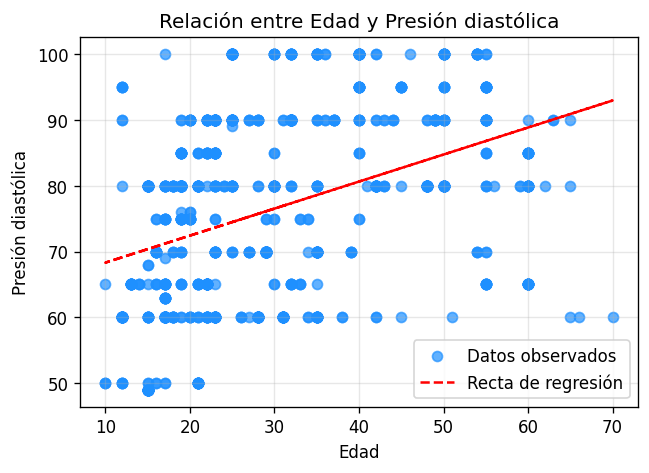

In [36]:
import statsmodels.api as sm

x_const = sm.add_constant(x)
modelo4 = sm.OLS(y, x_const).fit()
y_pred = modelo4.predict(x_const)

# Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(x, y, color="dodgerblue", alpha=0.7, label="Datos observados")
plt.plot(x, y_pred, color="red", linestyle="--", label="Recta de regresión")
plt.xlabel("Edad")
plt.ylabel("Presión diastólica")
plt.title("Relación entre Edad y Presión diastólica")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [37]:
print("Intercepto (b0):", modelo4.params[0])
print("Pendiente (b1):", modelo4.params[1])


Intercepto (b0): 64.20776549173617
Pendiente (b1): 0.41017912814062685


/tmp/ipykernel_28353/4279731089.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Intercepto (b0):", modelo4.params[0])
/tmp/ipykernel_28353/4279731089.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Pendiente (b1):", modelo4.params[1])


In [38]:
print(modelo4.summary())


                            OLS Regression Results                            
Dep. Variable:            DiastolicBP   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     190.5
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           7.84e-40
Time:                        19:17:48   Log-Likelihood:                -4018.6
No. Observations:                1014   AIC:                             8041.
Df Residuals:                    1012   BIC:                             8051.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.2078      0.974     65.937      0.0

In [39]:
from statsmodels.formula.api import ols
modelo_lineal4 = ols("DiastolicBP ~ Age", data=df).fit()
anova_tabla4 = sm.stats.anova_lm(modelo_lineal4)
print(anova_tabla4)


              df         sum_sq       mean_sq           F        PR(>F)
Age          1.0   30943.860840  30943.860840  190.507096  7.835632e-40
Residual  1012.0  164378.061251    162.428914         NaN           NaN


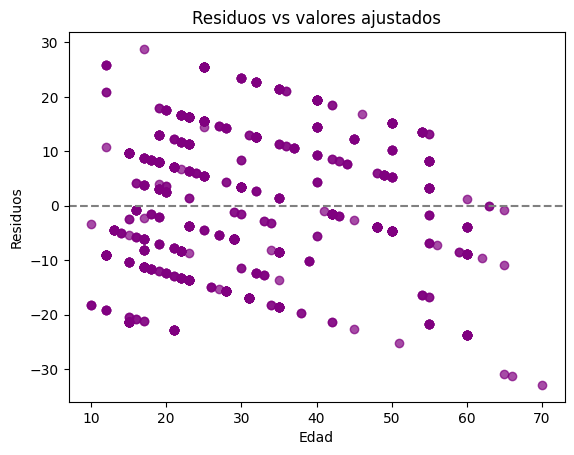

In [40]:
plt.scatter(x, modelo4.resid, color="purple", alpha=0.7)
plt.axhline(y=0, color="gray", linestyle="--")
plt.xlabel("Edad")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()


In [41]:
from statsmodels.stats.stattools import durbin_watson
dw4 = durbin_watson(modelo4.resid)
print("Durbin-Watson:", dw4)


Durbin-Watson: 1.9944299169930015


Shapiro-Wilk valor-p: 2.3379097545583248e-11


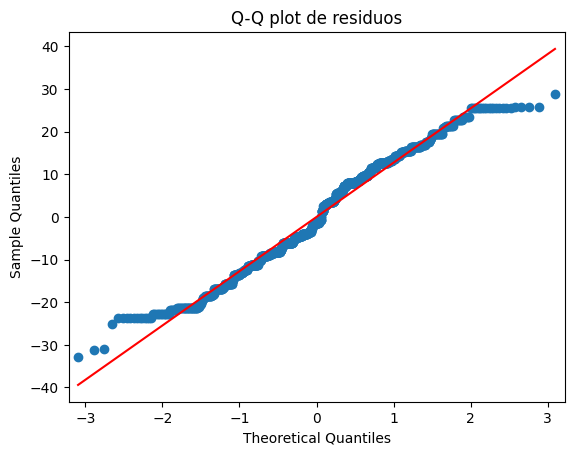

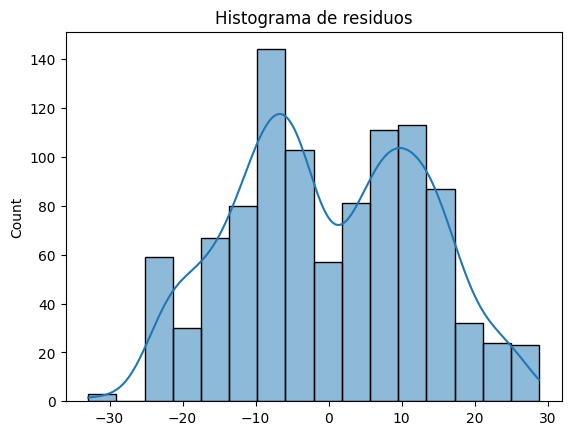

In [42]:
from scipy.stats import shapiro
stat, p_shapiro4 = shapiro(modelo4.resid)
print("Shapiro-Wilk valor-p:", p_shapiro4)

sm.qqplot(modelo4.resid, line="s")
plt.title("Q-Q plot de residuos")
plt.show()

import seaborn as sns
sns.histplot(modelo4.resid, kde=True)
plt.title("Histograma de residuos")
plt.show()


In [43]:
from statsmodels.stats.api import het_breuschpagan
bp_test4 = het_breuschpagan(modelo4.resid, x_const)
print("Breusch-Pagan valor-p:", bp_test4[1])


Breusch-Pagan valor-p: 0.6896548715961566


In [44]:
from scipy.stats import pearsonr
r4, p_valor4 = pearsonr(x, y)
print("Coeficiente de correlación:", r4)
print("Valor-p:", p_valor4)
print("Coeficiente de determinación (R2):", r4**2)


Coeficiente de correlación: 0.39802628670318413
Valor-p: 7.835631748556726e-40
Coeficiente de determinación (R2): 0.15842492490672533


In [45]:
valor4 = modelo4.predict([1,40])  # Ejemplo con Edad = 40 años
print("Estimación de presión diastólica:", valor4[0])


Estimación de presión diastólica: 80.61493061736124


## **Modelo 5: Relación entre Glucosa en sangre y Frecuencia cardiaca**

In [46]:
x = df["BS"]            # Variable independiente
y = df["HeartRate"]     # Variable dependiente


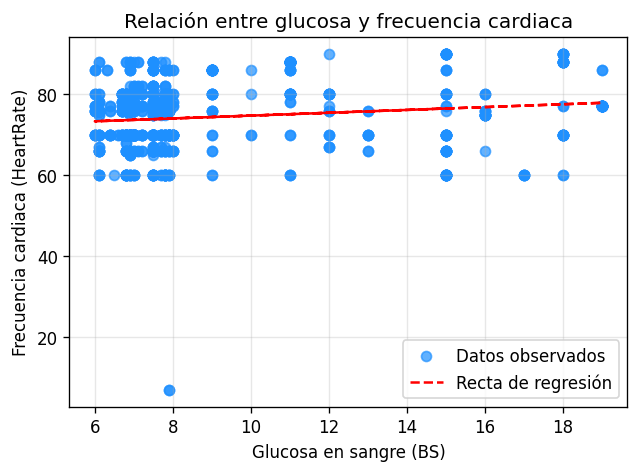

In [47]:
import statsmodels.api as sm

x_const = sm.add_constant(x)
modelo5 = sm.OLS(y, x_const).fit()
y_pred = modelo5.predict(x_const)

# Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(x, y, color="dodgerblue", alpha=0.7, label="Datos observados")
plt.plot(x, y_pred, color="red", linestyle="--", label="Recta de regresión")
plt.xlabel("Glucosa en sangre (BS)")
plt.ylabel("Frecuencia cardiaca (HeartRate)")
plt.title("Relación entre glucosa y frecuencia cardiaca")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [48]:
print("Intercepto (b0):", modelo5.params[0])
print("Pendiente (b1):", modelo5.params[1])


Intercepto (b0): 71.24006456607391
Pendiente (b1): 0.35087272819754367


/tmp/ipykernel_28353/2744519391.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Intercepto (b0):", modelo5.params[0])
/tmp/ipykernel_28353/2744519391.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Pendiente (b1):", modelo5.params[1])


In [49]:
print(modelo5.summary())


                            OLS Regression Results                            
Dep. Variable:              HeartRate   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     21.09
Date:                Fri, 17 Jul 2026   Prob (F-statistic):           4.94e-06
Time:                        19:17:50   Log-Likelihood:                -3547.6
No. Observations:                1014   AIC:                             7099.
Df Residuals:                    1012   BIC:                             7109.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.2401      0.713     99.969      0.0

In [50]:
from statsmodels.formula.api import ols
modelo_lineal5 = ols("HeartRate ~ BS", data=df).fit()
anova_tabla5 = sm.stats.anova_lm(modelo_lineal5)
print(anova_tabla5)


              df        sum_sq      mean_sq          F    PR(>F)
BS           1.0   1352.796198  1352.796198  21.086372  0.000005
Residual  1012.0  64924.860607    64.155001        NaN       NaN


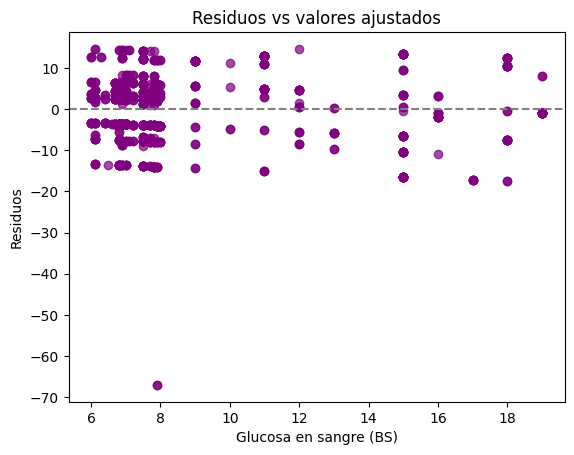

In [51]:
plt.scatter(x, modelo5.resid, color="purple", alpha=0.7)
plt.axhline(y=0, color="gray", linestyle="--")
plt.xlabel("Glucosa en sangre (BS)")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()


In [52]:
from statsmodels.stats.stattools import durbin_watson
dw5 = durbin_watson(modelo5.resid)
print("Durbin-Watson:", dw5)


Durbin-Watson: 2.1472059981602643


Shapiro-Wilk valor-p: 6.473001464673405e-23


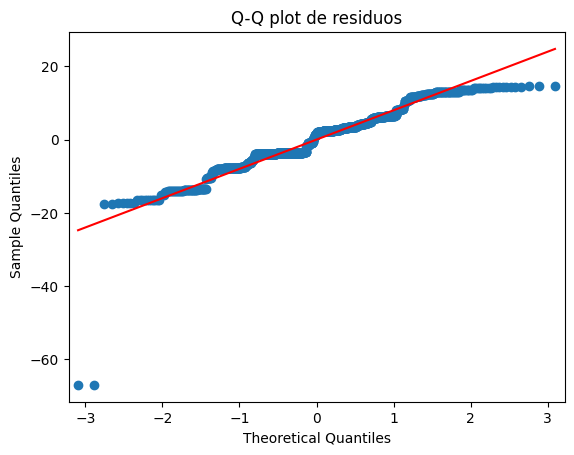

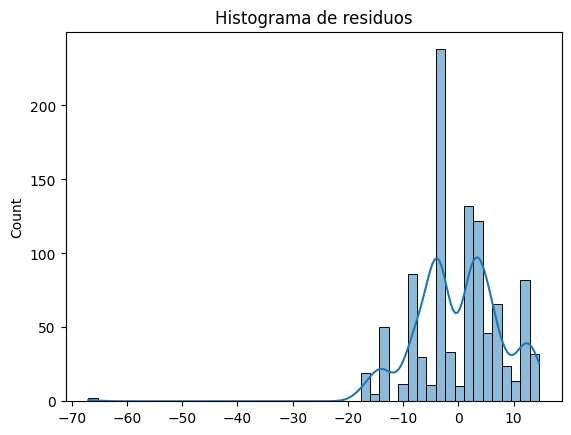

In [53]:
from scipy.stats import shapiro
stat, p_shapiro5 = shapiro(modelo5.resid)
print("Shapiro-Wilk valor-p:", p_shapiro5)

sm.qqplot(modelo5.resid, line="s")
plt.title("Q-Q plot de residuos")
plt.show()

import seaborn as sns
sns.histplot(modelo5.resid, kde=True)
plt.title("Histograma de residuos")
plt.show()


In [54]:
from statsmodels.stats.api import het_breuschpagan
bp_test5 = het_breuschpagan(modelo5.resid, x_const)
print("Breusch-Pagan valor-p:", bp_test5[1])


Breusch-Pagan valor-p: 0.019822754139662956


In [55]:
from scipy.stats import pearsonr
r5, p_valor5 = pearsonr(x, y)
print("Coeficiente de correlación:", r5)
print("Valor-p:", p_valor5)
print("Coeficiente de determinación (R2):", r5**2)


Coeficiente de correlación: 0.1428672265994146
Valor-p: 4.942595283013102e-06
Coeficiente de determinación (R2): 0.020411044436208475


In [56]:
valor5 = modelo5.predict([1,8])  # Ejemplo con BS = 8
print("Estimación de frecuencia cardiaca:", valor5[0])


Estimación de frecuencia cardiaca: 74.04704639165426
